In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Mall_Customers.csv")


In [3]:
#drop target not needed 
df.drop(columns = ["CustomerID", "Genre"], inplace = True)

In [4]:
#Encode categorical columns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
Cat_cols = df.select_dtypes(include = ["object", "category"]).columns.tolist()
for col in Cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [5]:
#impute missing values 
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(),inplace = True)

In [6]:
#scale features (mandatory for K-Means-distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

In [7]:
print("datasetshape:", df.shape)
print("features used", df.columns.tolist())

datasetshape: (200, 3)
features used ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


ELBOW METHOD- INERTIA VS K 

In [8]:

from sklearn.cluster import KMeans
k_range = range(2, 11) #Test K=2 through 10
inertias = []
for k in k_range:
    km = KMeans(
    n_clusters=k,
    init='k-means++',
    n_init=10,
    max_iter=300,        
    random_state=42      
)

    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print (f" K = {k:2d} Inertia = {km.inertia_:.2f}")

 K =  2 Inertia = 389.39
 K =  3 Inertia = 295.21
 K =  4 Inertia = 205.23
 K =  5 Inertia = 168.25
 K =  6 Inertia = 133.87
 K =  7 Inertia = 117.01
 K =  8 Inertia = 103.87
 K =  9 Inertia = 93.09
 K = 10 Inertia = 82.39


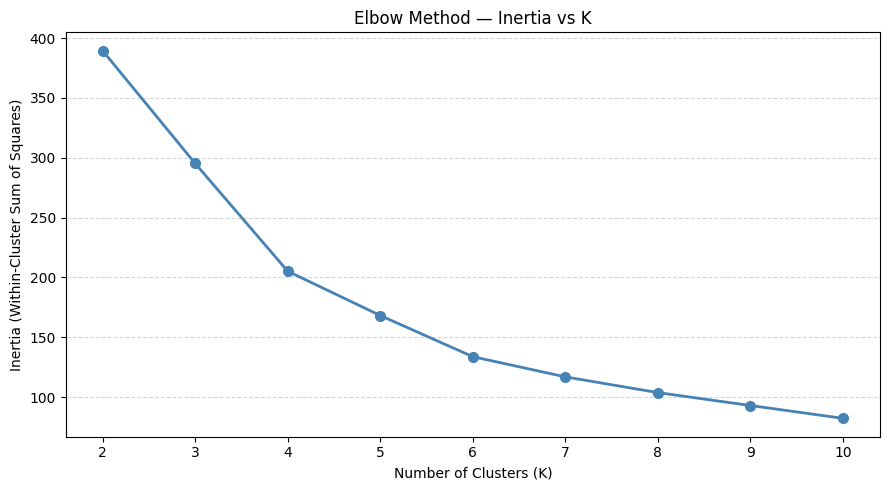

In [9]:
# plot elbow curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue',
         linewidth=2, markersize=7)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method — Inertia vs K")
plt.xticks(k_range)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("kmeans_elbow.png", dpi=150)
plt.show()




In [10]:

#Silhoutte score (confirm the best k)
from sklearn.metrics import silhouette_score 


##SILHOUETTE SCORE (CONFIRM THE BEST K)
SCORE RANGES FROM -1 TO +1 higher is better 

In [11]:
k_range  = range(2, 11)
sil_scores = []
 
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  K = {k:2d}   Silhouette Score = {score:.4f}")
 
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nBest K by Silhouette Score: {best_k}")
 



  K =  2   Silhouette Score = 0.3355
  K =  3   Silhouette Score = 0.3578
  K =  4   Silhouette Score = 0.4040
  K =  5   Silhouette Score = 0.4166
  K =  6   Silhouette Score = 0.4284
  K =  7   Silhouette Score = 0.4172
  K =  8   Silhouette Score = 0.4082
  K =  9   Silhouette Score = 0.4177
  K = 10   Silhouette Score = 0.4066

Best K by Silhouette Score: 6


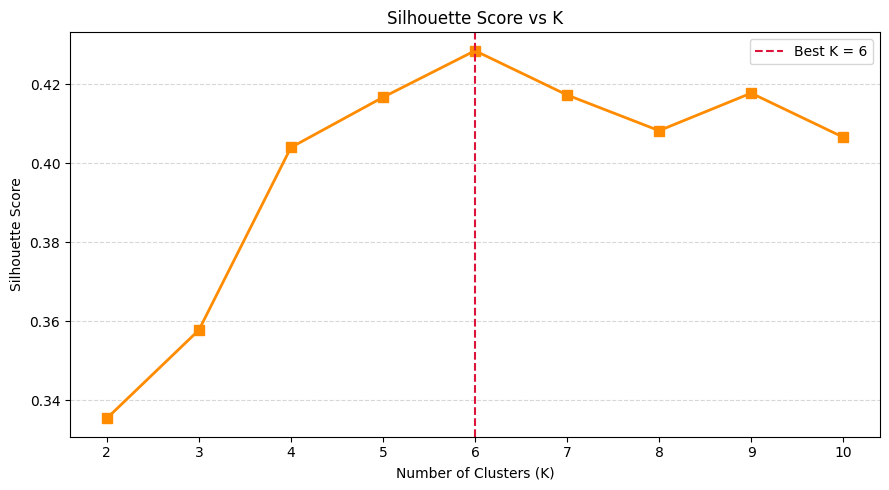

In [12]:
# Plot silhouette scores
plt.figure(figsize=(9, 5))
plt.plot(k_range, sil_scores, marker='s', color='darkorange',
         linewidth=2, markersize=7)
plt.axvline(best_k, color='crimson', linestyle='--',
            label=f'Best K = {best_k}')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(k_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("kmeans_silhouette.png", dpi=150)
plt.show()

FIT FINAL MODEL

In [13]:
#fit final model with chosen best_k
from sklearn.cluster import KMeans
best_k = 4 
km_final = KMeans(
    n_clusters = best_k,
    init = "k-means++",
    n_init=10,
    max_iter=300,
    tol = 1e-4,
    random_state=42
)
km_final.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
#Assign cluster labels back to original dataframe 
df['cluster'] = km_final.labels_

print(f"Final k  :{best_k}")
print("Final Inertia  : {km_final.inertia_:.4f}")
print(f"Iterations taken : {km_final.n_iter_}")
print(f"\ncluster counts:")
print(df['cluster'].value_counts().sort_index())

Final k  :4
Final Inertia  : {km_final.inertia_:.4f}
Iterations taken : 5

cluster counts:
cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


GROUP BY CLUSTER 

In [15]:
import seaborn as sns 
#Mean of evert feature per cluster 
cluster_means = df.groupby ('cluster').mean().round(3)
print("\n---cluster Means (original scale )---")
print(cluster_means.to_string())



---cluster Means (original scale )---
            Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                    
0        53.985              47.708                  39.969
1        32.875              86.100                  81.525
2        25.439              40.000                  60.298
3        39.368              86.500                  19.579


In [16]:
#FULL DESCRIPTIVE STATS PER CLUSTER 
print("\n---cluster descriptive statistics---")
for c in sorted (df['cluster'].unique()):
    print(f"\n cluster {c} (n = {(df['cluster']==c).sum()}")
    print(df[df['cluster']==c].describe().round(3).to_string())


---cluster descriptive statistics---

 cluster 0 (n = 65
          Age  Annual Income (k$)  Spending Score (1-100)  cluster
count  65.000              65.000                  65.000     65.0
mean   53.985              47.708                  39.969      0.0
std     9.418              14.649                  16.406      0.0
min    35.000              18.000                   3.000      0.0
25%    48.000              39.000                  32.000      0.0
50%    52.000              49.000                  46.000      0.0
75%    63.000              60.000                  51.000      0.0
max    70.000              79.000                  60.000      0.0

 cluster 1 (n = 40
          Age  Annual Income (k$)  Spending Score (1-100)  cluster
count  40.000              40.000                  40.000     40.0
mean   32.875              86.100                  81.525      1.0
std     3.858              16.339                  10.000      0.0
min    27.000              69.000                  

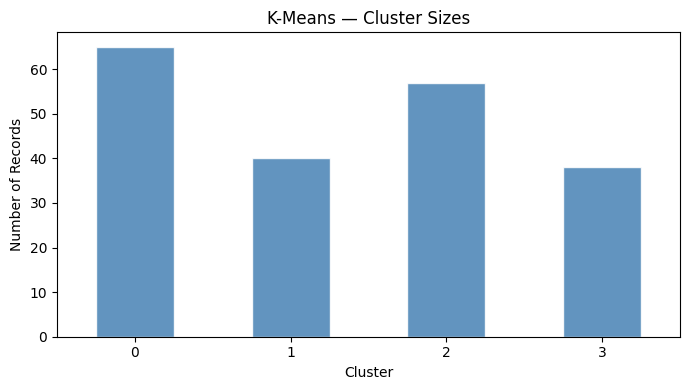

In [17]:
#cluster size bar chart
plt.figure(figsize=(7, 4))
df['cluster'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', alpha=0.85, edgecolor='white')
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.title("K-Means — Cluster Sizes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("kmeans_cluster_sizes.png", dpi=150)
plt.show()


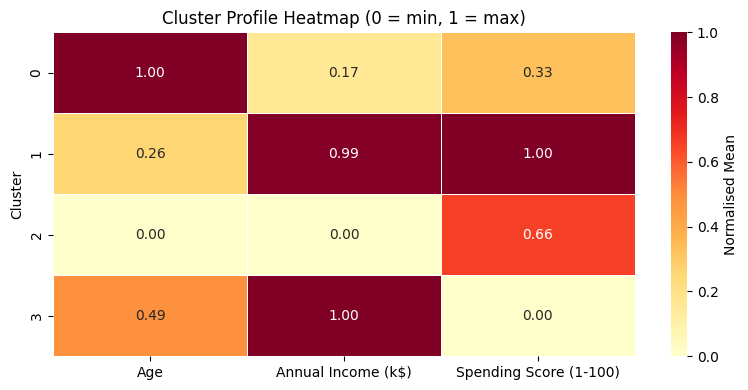

In [18]:
#HEATMAP OF CLUSTER MEANS (normalised for easy comparison)
norm_means = (cluster_means - cluster_means.min())/(
    cluster_means.max() - cluster_means.min())

plt.figure(figsize=(max(8, len(df.columns)*0.8), 4))
sns.heatmap(norm_means, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={'label': 'Normalised Mean'})
plt.title("Cluster Profile Heatmap (0 = min, 1 = max)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("kmeans_cluster_heatmap.png", dpi=150)
plt.show()


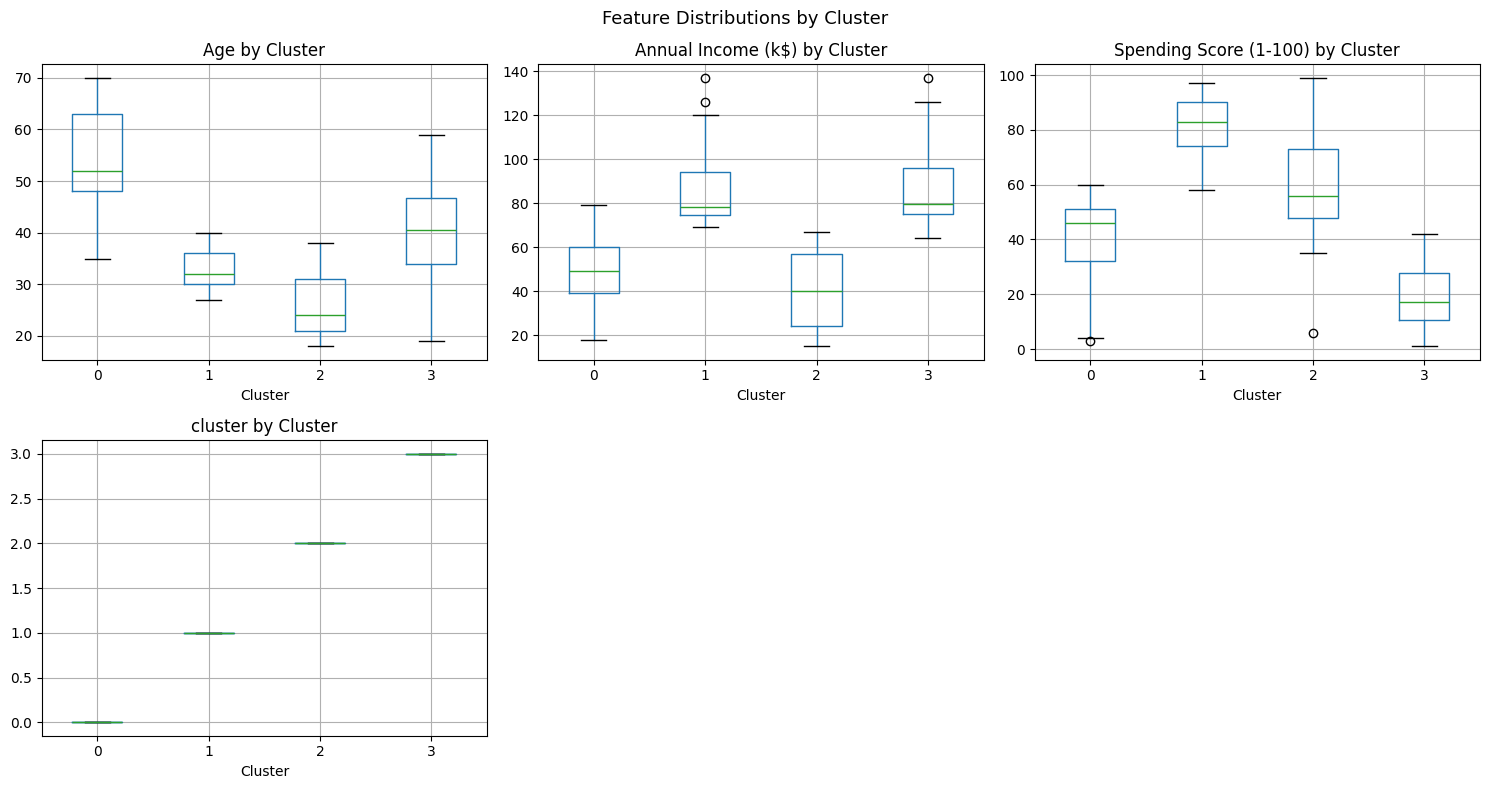

In [19]:
# 4e. Box plots — each feature by cluster
feature_cols = [c for c in df.columns if c != 'Cluster']
n_feat = len(feature_cols)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols 

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_feat > 1 else [axes]
 
for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='cluster', ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
 
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Feature Distributions by Cluster", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_boxplots_by_cluster.png", dpi=150)
plt.show()



VISUALISE CLUSTERS

In [20]:
from sklearn.decomposition import PCA

In [21]:
#2D PCA scatter (works for any number of features)
pca2 = PCA(n_components= 2, random_state = 43)
x_2d = pca2.fit_transform(X_scaled)

C:\Users\USER\AppData\Local\Temp\ipykernel_9144\2432895198.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('Set2', best_k)


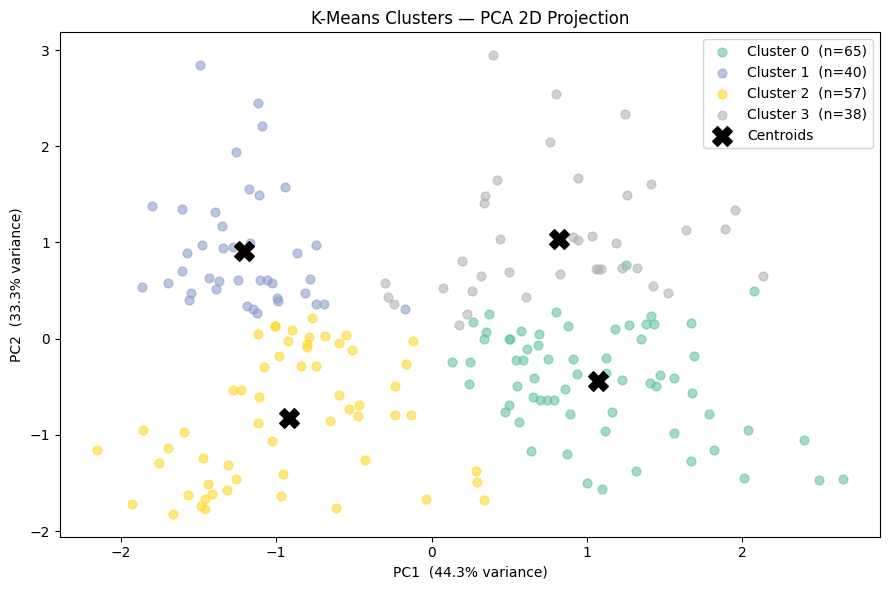

In [35]:
# ── 5a. 2D PCA scatter (works for any number of features) ───
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)
 
# Centroids in PCA space
centroids_2d = pca2.transform(km_final.cluster_centers_)
 
plt.figure(figsize=(9, 6))
palette = plt.cm.get_cmap('Set2', best_k)
for c in range(best_k):
    mask = df['cluster'] == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=palette(c), alpha=0.6, s=40,
                label=f'Cluster {c}  (n={mask.sum()})')
 
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            marker='X', s=200, c='black',
            zorder=5, label='Centroids')
plt.xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title("K-Means Clusters — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150)
plt.show()


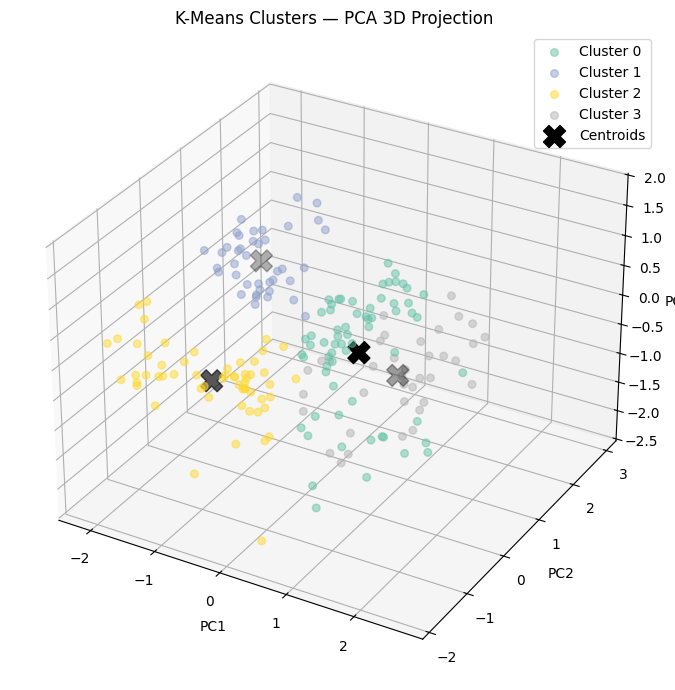

In [37]:
#5b. 3D PCA scatter (optional )
pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_scaled)
centroids_3d = pca3.transform(km_final.cluster_centers_)
 
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
 
for c in range(best_k):
    mask = df['cluster'] == c
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               color=palette(c), alpha=0.5, s=30,
               label=f'Cluster {c}')
 
ax.scatter(centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
           marker='X', s=250, c='black', zorder=5, label='Centroids')
 
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("K-Means Clusters — PCA 3D Projection")
ax.legend()
plt.tight_layout()
plt.savefig("kmeans_pca3d.png", dpi=150)
plt.show()
